# Pandas basics

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("countries.csv") #dataframe
df.head() # showing first 5 lines

,country,continent,life_expectancy,population,gdp
0,Afghanistan,Asia,54.863,22856302,15153728226
1,Albania,Europe,74.200,3071856,12886435920
2,Algeria,Africa,68.963,30533827,155661450046
3,Angola,Africa,45.234,13926373,34063908358
4,Antigua and Barbuda,N. America,73.544,77656,989182128


In [3]:
df.tail() # last 5 rows

,country,continent,life_expectancy,population,gdp
183,Vietnam,Asia,73.777,78758010,124201381770
184,West Bank and Gaza,Asia,70.929,3198560,24264276160
185,"Yemen, Rep.",Asia,60.404,17723186,39292303362
186,Zambia,Africa,41.802,10201562,10558616670
187,Zimbabwe,Africa,43.976,12509477,9319560365


In [4]:
df.shape # num of rows and num of columns

(188, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          188 non-null    object 
 1   continent        188 non-null    object 
 2   life_expectancy  188 non-null    float64
 3   population       188 non-null    int64  
 4   gdp              188 non-null    int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 7.5+ KB


In [6]:
df.dtypes

country             object
continent           object
life_expectancy    float64
population           int64
gdp                  int64
dtype: object

## Let's figure out questions to ask this dataset

1. Which country has highest GDP per capita
2. Which country has highest and lowest life_expectancy
3. Average life_expectancy of every continent


In [7]:
# the highest life expectancy
# pretend this is a list of dictionaries
# and all of your dreams could be true

print(df["life_expectancy"].max())

81.35


In [8]:
df.sort_values(by="life_expectancy") # we can skip writing by=
df.sort_values("life_expectancy", ascending=False).head(10)

,country,continent,life_expectancy,population,gdp
83,Japan,Asia,81.350,125720310,3590446333290
72,"Hong Kong, China",Asia,80.361,6783317,203309577124
161,Switzerland,Europe,79.990,7167908,246475684488
7,Australia,Oceania,79.930,19164351,560384787591
160,Sweden,Europe,79.840,8860153,253754781920
81,Italy,Europe,79.730,56986329,1547748695640
74,Iceland,Europe,79.720,281210,8743381320
29,Canada,N. America,79.410,30667365,995094659520
155,Spain,Europe,79.340,40288457,943152778370
57,France,Europe,79.230,59047795,1690892657620


In [9]:
# highest life expectancy in Europe
df[df['continent'] == "Europe"] # how to filter only Europe from dataframe

,country,continent,life_expectancy,population,gdp
1,Albania,Europe,74.200000,3071856,12886435920
6,Armenia,Europe,71.494000,3076098,6502871172
8,Austria,Europe,78.330000,8004712,256214821696
9,Azerbaijan,Europe,66.851000,8110723,20544461359
14,Belarus,Europe,68.990000,10057810,59703160160
15,Belgium,Europe,77.910000,10175684,304659978960
20,Bosnia and Herzegovina,Europe,74.882000,3693698,21175970634
24,Bulgaria,Europe,71.590000,8006158,55298533306
41,Croatia,Europe,74.798000,4505533,47677550206
43,Cyprus,Europe,78.011000,943294,21526912374


In [10]:
# get the median life exp in Europe
df[df['continent'] == "Europe"]['life_expectancy'].median()

np.float64(75.58)

In [11]:
# another way to do this with loc 
df.loc[df["continent"] == "Europe", 'life_expectancy'].median()

np.float64(75.58)

In [12]:
df[df['continent'] == "Africa"]['life_expectancy'].median()

np.float64(52.1025)

In [ ]:
# Put it into groups
# life expectancy
# get the median
df.groupby("continent")['life_expectancy'].median()

continent
Africa        52.1025
Asia          70.4275
Europe        75.5800
N. America    70.5765
Oceania       67.4955
S. America    70.7660
Name: life_expectancy, dtype: float64

In [14]:
# sorting this thing (series)

df.groupby("continent")['life_expectancy'].median().sort_values(ascending=False)

continent
Europe        75.5800
S. America    70.7660
N. America    70.5765
Asia          70.4275
Oceania       67.4955
Africa        52.1025
Name: life_expectancy, dtype: float64

In [15]:


df['gdp_per_capita'] = df['gdp']/df["population"]
df.head()

,country,continent,life_expectancy,population,gdp,gdp_per_capita
0,Afghanistan,Asia,54.863,22856302,15153728226,663.0
1,Albania,Europe,74.200,3071856,12886435920,4195.0
2,Algeria,Africa,68.963,30533827,155661450046,5098.0
3,Angola,Africa,45.234,13926373,34063908358,2446.0
4,Antigua and Barbuda,N. America,73.544,77656,989182128,12738.0


In [16]:
df.to_csv("countries-cleaned.csv", index=False) # to not save indexes

In [17]:
df['life_expectancy'].describe()

count    188.000000
mean      66.501536
std       10.298458
min       38.123000
25%       59.663750
50%       70.041500
75%       74.134500
max       81.350000
Name: life_expectancy, dtype: float64

In [ ]:
# how many countries
df['continent'].value_counts()

continent
Africa        54
Asia          48
Europe        42
N. America    22
S. America    12
Oceania       10
Name: count, dtype: int64

In [33]:
df['continent'].value_counts(normalize=True)

continent
Africa        0.287234
Asia          0.255319
Europe        0.223404
N. America    0.117021
S. America    0.063830
Oceania       0.053191
Name: proportion, dtype: float64

In [34]:
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

<Axes: xlabel='continent'>

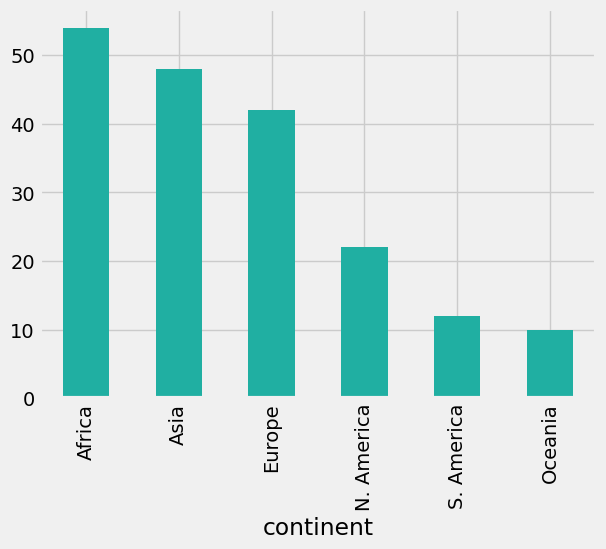

In [39]:
df['continent'].value_counts().plot(kind="bar", color="#20afa2")